# SVD Landscape Fine-tuning
Run each cell in order. Make sure you have an **A100 GPU** selected:
> Runtime → Change runtime type → A100 GPU

In [ ]:
# ── 1. Check GPU ────────────────────────────────────────────────────────────
!nvidia-smi

Sat Mar 14 20:19:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ── 2. Install dependencies ──────────────────────────────────────────────────
!pip install -q \
    yt-dlp \
    opencv-python-headless \
    diffusers[torch] \
    transformers \
    accelerate \
    peft \
    imageio[ffmpeg] \
    tqdm \
    Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.4/182.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 127.3 MB/s eta 0:00:00


In [ ]:
# ── 3. (Optional) Mount Google Drive to persist data/checkpoints ─────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Change these if you want to save elsewhere
DATA_DIR   = '/content/drive/MyDrive/svd_landscape/data'
CKPT_DIR   = '/content/drive/MyDrive/svd_landscape/checkpoints'

Mounted at /content/drive


In [ ]:
# ── 4. Upload scripts ────────────────────────────────────────────────────────
# Upload make_dataset_svd.py and train_svd_lora.py using the file panel on the left,
# or run this cell to download them if hosted somewhere.
# (Replace URLs with your actual hosted script URLs if needed)

# If you uploaded them manually, just verify they're here:
!ln -s /content/drive/MyDrive/SVD/make_dataset_svd.py
!ln -s /content/drive/MyDrive/SVD/train_svd_lora.py

In [ ]:
# ── 5. Extract dataset ───────────────────────────────────────────────────────

!python /content/make_dataset_svd.py \
    --url   'https://www.youtube.com/watch?v=AKeUssuu3Is' \
    --out   $DATA_DIR \
    --clip_len 14 \
    --fps      7 \
    --size     512 \
    --interval 4.0 \
    --max_clips 2000


Usage: yt-dlp [OPTIONS] URL [URL...]

yt-dlp: error: invalid http retry sleep expression 'exponential=1:30'
Traceback (most recent call last):
  File "/content/make_dataset_svd.py", line 225, in <module>
    extract_clips(
  File "/content/make_dataset_svd.py", line 113, in extract_clips
    local_path, video_fps = download_video(youtube_url, tmp_video)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/make_dataset_svd.py", line 43, in download_video
    subprocess.run(cmd, check=True)
  File "/usr/lib/python3.12/subprocess.py", line 571, in run
    raise CalledProcessError(retcode, process.args,
subprocess.CalledProcessError: Command '['yt-dlp', '-f', '136', '--retries', '20', '--fragment-retries', '20', '--retry-sleep', 'exponential=1:30', '--concurrent-fragments', '4', '--buffer-size', '16K', '--http-chunk-size', '10M', '-o', '/content/tmp_landscape.mp4', 'https://www.youtube.com/watch?v=AKeUssuu3Is']' returned non-zero exit status 2.


Total clips: 2000


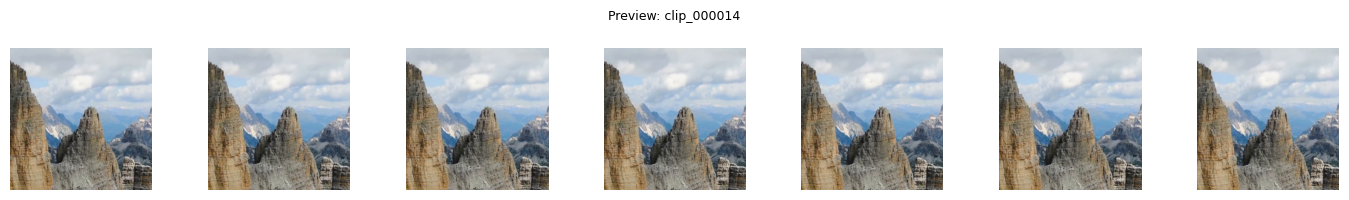

In [ ]:
# ── 6. Verify dataset ────────────────────────────────────────────────────────
import os
clips = [d for d in os.listdir(DATA_DIR) if d.startswith('clip_')]
print(f'Total clips: {len(clips)}')

# Preview first clip
from PIL import Image
import matplotlib.pyplot as plt

first_clip = sorted(clips)[14]
frames = sorted(os.listdir(os.path.join(DATA_DIR, first_clip)))
fig, axes = plt.subplots(1, min(7, len(frames)), figsize=(14, 2))
for ax, fname in zip(axes, frames[:7]):
    ax.imshow(Image.open(os.path.join(DATA_DIR, first_clip, fname)))
    ax.axis('off')
plt.suptitle(f'Preview: {first_clip}', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7. Login to HuggingFace (needed to download SVD weights) ─────────────────
# Get your token at https://huggingface.co/settings/tokens
from huggingface_hub import login
login()  # will prompt for token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ── 8. Train ─────────────────────────────────────────────────────────────────
# Expected time on A100: ~1.5–2.5h for 2000 clips × 3 epochs
# Watch for 'New best saved' lines — that means it's learning.

!python /content/train_svd_lora.py \
    --data_dir         $DATA_DIR \
    --output_dir       $CKPT_DIR \
    --clip_len         14 \
    --size             512 \
    --epochs           3 \
    --batch_size       1 \
    --lr               1e-4 \
    --lora_rank        16 \
    --fps_id           7 \
    --motion_bucket_id 127

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[17:04:35] Device: cuda | dtype: torch.bfloat16
[17:04:35] Loading SVD pipeline...
Loading pipeline components...:  40% 2/5 [00:00<00:00, 13.10it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 12052.60it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 2003.97it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 2401.55it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 2075.36it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   1% 3/520 

In [ ]:
import shutil
import os

# Prendre la première frame du premier clip
first_clip = sorted(os.listdir('/content/drive/MyDrive/svd_landscape/data'))[14]
first_frame = f'/content/drive/MyDrive/svd_landscape/data/{first_clip}/frame_000.jpg'
shutil.copy(first_frame, '/content/test_landscape.jpg')
print(f"Copié depuis {first_frame}")

Copié depuis /content/drive/MyDrive/svd_landscape/data/clip_000014/frame_000.jpg


In [ ]:
# ── 9. Quick inference test ──────────────────────────────────────────────────
# Upload a landscape image to /content/test_landscape.jpg first
import glob
lora_best = glob.glob(f'{CKPT_DIR}/run_*/lora_best')[0]
print(f'Using LoRA from: {lora_best}')

!python /content/train_svd_lora.py \
    --infer \
    --lora_dir   $lora_best \
    --image_path /content/test_landscape.jpg

Using LoRA from: /content/drive/MyDrive/svd_landscape/checkpoints/run_20260314_170440/lora_best
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline for inference...
Loading pipeline components...:  20% 1/5 [00:00<00:01,  2.40it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 14027.77it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 5991.86it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 4183.84it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 3364.86it/s, Materializing param=vision_model.embeddings.patch

In [ ]:
# ── 10. Display output video ──────────────────────────────────────────────────
from IPython.display import Video
Video('output.mp4', embed=True)

## Scaling up to 5000 images and longer video spans

In [ ]:
DATA_DIR   = '/content/drive/MyDrive/svd_landscape/data_v2'
CKPT_DIR   = '/content/drive/MyDrive/svd_landscape/checkpoints2'

In [ ]:
!python /content/make_dataset_svd.py \
    --url 'https://www.youtube.com/watch?v=AKeUssuu3Is' \
    --out DATA_DIR \
    --frame_gap 25 \
    --interval 0.5 \
    --max_clips 5000 \
    --motion_min 3.0 \
    --motion_max 40.0

Video already exists at /content/tmp_landscape.mp4, skipping download.
Video FPS: 24.0
Frame gap: 25 frames source par frame de clip
Mouvement capturé par clip: 14.6s de vidéo source
Motion filter: [3.0, 40.0]
Clips extracted: 877clips [24:38,  1.69s/clips, motion=8.1, rejected_static=55]

Done. 877 clips saved.
Rejected — static: 56 | scene cuts: 0
Each clip spans 14.6s of source video


In [ ]:
!python /content/train_svd_lora.py \
    --data_dir         $DATA_DIR \
    --output_dir       $CKPT_DIR \
    --clip_len         14 \
    --size             512 \
    --epochs           3 \
    --batch_size       1 \
    --lr               1e-4 \
    --lora_rank        16 \
    --fps_id           7 \
    --motion_bucket_id 127

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[21:17:47] Device: cuda | dtype: torch.bfloat16
[21:17:47] Loading SVD pipeline...
model_index.json: 100% 498/498 [00:00<00:00, 3.21MB/s]
Fetching 9 files: 100% 9/9 [00:13<00:00,  1.49s/it]
Download complete: 100% 4.51G/4.51G [00:13<00:00, 210MB/s]                
Download complete: 100% 4.51G/4.51G [00:13<00:00, 335MB/s]

Loading weights: 100% 520/520 [00:00<00:00, 735.14it/s, Materializing param=visual_projection.weight]

Loading pipeline components...:  40% 2/5 [00:02<00:02,  1.02it/s]
Loading pipeline components...:  80% 4/5 [00:02<00:00,  2.51it/s]
Loading pipeline components...: 100% 5/5 [00:02<00:00,  2.24it/s]
trainable params: 3,319,808 || all params: 1,527,942,890 || trainable%: 0.21

In [ ]:
import shutil
import os

# Prendre la première frame du premier clip
first_clip = sorted(os.listdir('/content/drive/MyDrive/svd_landscape/data'))[14]
first_frame = f'/content/drive/MyDrive/svd_landscape/data/{first_clip}/frame_000.jpg'
shutil.copy(first_frame, '/content/test_landscape.jpg')
print(f"Copié depuis {first_frame}")

Copié depuis /content/drive/MyDrive/svd_landscape/data/clip_000014/frame_000.jpg


In [ ]:
# ── 9. Quick inference test ──────────────────────────────────────────────────
# Upload a landscape image to /content/test_landscape.jpg first
import glob
lora_best = glob.glob(f'{CKPT_DIR}/run_*/lora_best')[0]
print(f'Using LoRA from: {lora_best}')

!python /content/train_svd_lora.py \
    --infer \
    --lora_dir   $lora_best \
    --image_path /content/test_landscape.jpg

Using LoRA from: /content/drive/MyDrive/svd_landscape/checkpoints2/run_20260314_211805/lora_best
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline for inference...
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 13400.33it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 4696.87it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 2009.73it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 1093.83it/s, Materializing param=vision_model.embeddings.patch_embedd

In [ ]:
# ── 10. Display output video ──────────────────────────────────────────────────
from IPython.display import Video
Video('output.mp4', embed=True)

## Shorter video span doubling lora rank to 32

### Dataset extracted on other notebook

In [ ]:
DATA_DIR   = '/content/drive/MyDrive/svd_landscape/data_v3'
CKPT_DIR   = '/content/drive/MyDrive/svd_landscape/checkpoints3'

In [ ]:
# ── 5. Extract dataset ───────────────────────────────────────────────────────
!python /content/make_dataset_svd.py \
    --url 'https://www.youtube.com/watch?v=AKeUssuu3Is' \
    --out {DATA_DIR} \
    --frame_gap 12 \
    --interval 7.0 \
    --max_clips 5000 \
    --motion_min 3.0 \
    --motion_max 40.0

Video already exists at /content/tmp_landscape.mp4, skipping download.
Video FPS: 24.0
Frame gap: 12 frames source par frame de clip
Mouvement capturé par clip: 7.0s de vidéo source
Motion filter: [3.0, 40.0]
Clips extracted: 2374clips [33:24,  1.18clips/s, motion=7.8, rejected_static=258]

Done. 2374 clips saved.
Rejected — static: 261 | scene cuts: 0
Each clip spans 7.0s of source video


In [36]:
!python /content/train_svd_lora.py \
    --data_dir         $DATA_DIR \
    --output_dir       $CKPT_DIR \
    --clip_len         14 \
    --size             512 \
    --epochs           14 \
    --batch_size       1 \
    --lr               1e-4 \
    --lora_rank        32 \
    --fps_id           7 \
    --motion_bucket_id 127

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[23:02:36] Device: cuda | dtype: torch.bfloat16
[23:02:36] Loading SVD pipeline...
Loading pipeline components...:  20% 1/5 [00:01<00:06,  1.60s/it]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 9986.44it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 2826.35it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 2/520 [00:00<00:00, 547.74it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 530.92it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   1% 3/520 [00:

In [49]:
import shutil
import os

# Prendre la première frame du premier clip
first_clip = sorted(os.listdir('/content/drive/MyDrive/svd_landscape/data'))[25]
first_frame = f'/content/drive/MyDrive/svd_landscape/data/{first_clip}/frame_000.jpg'
shutil.copy(first_frame, '/content/test_landscape.jpg')
print(f"Copié depuis {first_frame}")

Copié depuis /content/drive/MyDrive/svd_landscape/data/clip_000025/frame_000.jpg


In [50]:
# ── 9. Quick inference test ──────────────────────────────────────────────────
# Upload a landscape image to /content/test_landscape.jpg first
import glob
lora_best = glob.glob(f'{CKPT_DIR}/run_*/lora_best')[0]
print(f'Using LoRA from: {lora_best}')

!python /content/train_svd_lora.py \
    --infer \
    --lora_dir   $lora_best \
    --image_path /content/test_landscape.jpg

Using LoRA from: /content/drive/MyDrive/svd_landscape/checkpoints3/run_20260314_230242/lora_best
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline for inference...
Loading pipeline components...:  20% 1/5 [00:00<00:01,  2.40it/s]
Loading weights:   0% 0/520 [00:00<?, ?it/s]
Loading weights:   0% 1/520 [00:00<00:00, 12865.96it/s, Materializing param=vision_model.embeddings.class_embedding]
Loading weights:   0% 1/520 [00:00<00:00, 3015.32it/s, Materializing param=vision_model.embeddings.class_embedding] 
Loading weights:   0% 2/520 [00:00<00:00, 3620.46it/s, Materializing param=vision_model.embeddings.patch_embedding.weight]
Loading weights:   0% 2/520 [00:00<00:00, 2319.22it/s, Materializing param=vision_model.embeddings.patc

In [51]:
from IPython.display import Video
Video('output.mp4', embed=True)